# 🏙️ SVHN Street Digit Recognition — Deep Learning


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

## Project Summary

Google Street View photographs millions of addresses worldwide. Automatically reading house numbers from raw pixel data is what lets Google Maps pinpoint building locations without human transcription. This project replicates that exact problem using the **SVHN (Street View House Numbers)** dataset — 60,000 labeled digit images cropped from real street-level photos.

I build and compare four neural network architectures:
- **ANN Model 1** — small fully connected network (baseline)
- **ANN Model 2** — wider and deeper ANN with Dropout and BatchNorm
- **CNN Model 1** — convolutional layers for spatial feature extraction
- **CNN Model 2** — deeper CNN with BatchNormalization and Dropout

Each model builds on the last, and the observations explain *why* each change improves performance.

---

## Table of Contents
1. Setup & Imports
2. Load Dataset
3. Exploratory Data Analysis
4. Data Preprocessing — ANN
5. ANN Model 1 (Baseline)
6. ANN Model 2 (Wider)
7. Data Preprocessing — CNN
8. CNN Model 1
9. CNN Model 2 (Best Model)
10. Final Evaluation & Model Comparison

---
## 1. Setup & Imports

We mount Google Drive (where our `.h5` dataset is stored) and import all required libraries. Random seeds are set globally to ensure results are reproducible — running the notebook twice will give identical accuracy numbers.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
print(f' Tensorflow version {tf.__version__}')

 Tensorflow version 2.20.0


---
## 2. Load Dataset

The dataset is stored in HDF5 format (`.h5`) — an efficient binary format designed for large numerical arrays. We load train and test splits directly into NumPy arrays.

In [42]:
DATA_PATH= '/content/drive/MyDrive/MIT- Applied AI and DS/Project_1_Deep_learning_CNN/SVHN_single_grey1.h5'

with h5py.File(DATA_PATH, "r") as hf:
  print("Keys in the file:", list(hf.keys()))
  X_train = hf["X_train"][:]
  y_train = hf["y_train"][:]
  X_test = hf["X_test"][:]
  y_test = hf["y_test"][:]

y_train[y_train == 10] = 0
y_test[y_test == 10] = 0

print("\n data loaded successfully")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Keys in the file: ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']

 data loaded successfully
X_train shape: (42000, 32, 32)
y_train shape: (42000,)
X_test shape: (18000, 32, 32)
y_test shape: (18000,)


In [43]:
print(f"Training_images : {X_train.shape[0]:,}")
print(f"Test images     : {X_test.shape[0]:,}")
print(f"Image Dimensions: {X_train.shape[1:]} (height x width x channels)")
print(f"Unique labels.  : {np.unique(y_train)}")
print(f"Pixel value range: {X_train.min()} to {X_train.max()}")

Training_images : 42,000
Test images     : 18,000
Image Dimensions: (32, 32) (height x width x channels)
Unique labels.  : [0 1 2 3 4 5 6 7 8 9]
Pixel value range: 0.0 to 254.97450256347656


**Observation:**

- The dataset contains 32×32 grayscale images (single channel)
- Pixel values are in the range 0–255 and need to be normalized before training
- Labels include class `10` — the SVHN convention for digit **0**. Without fixing this, one-hot encoding creates 11 classes instead of 10, breaking our output layer. We remap it during preprocessing.
- 42,000 training and 18,000 test images gives a solid 70/30 split

---
## 3. Exploratory Data Analysis

Before building any model, we examine the raw data. This builds intuition for what the network needs to learn and surfaces quirks (like the class-10 label) before they cause silent bugs downstream.

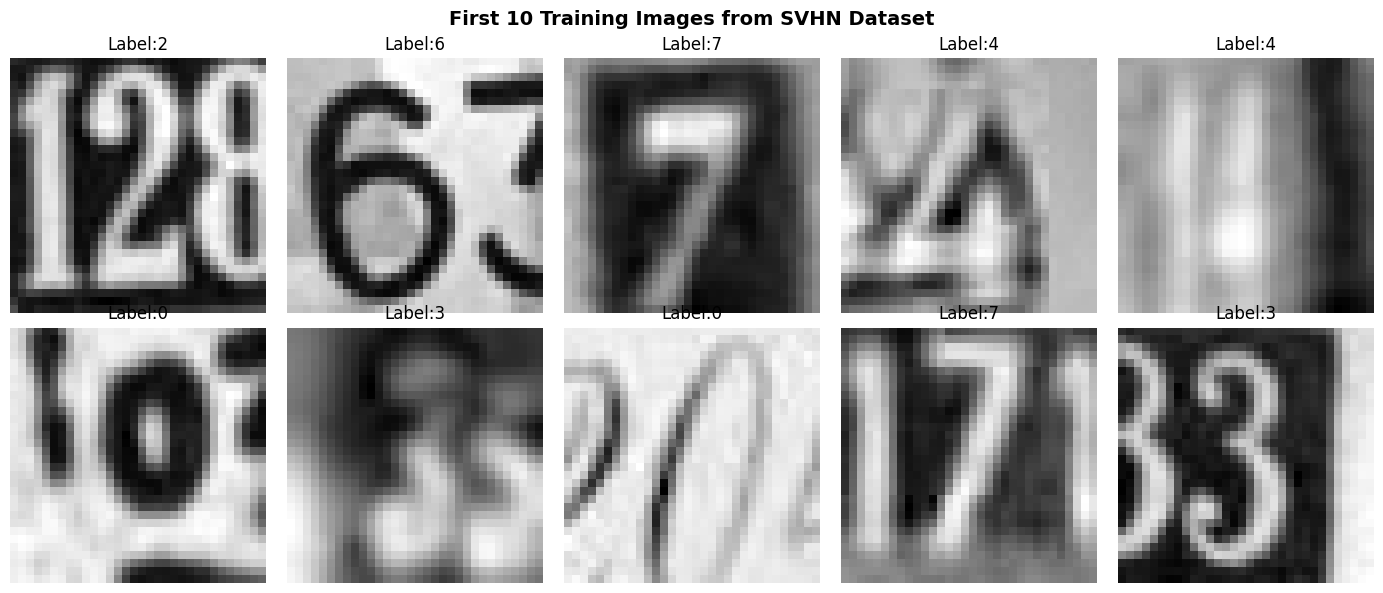

First 10 raw labels: [2 6 7 4 4 0 3 0 7 3]


In [44]:
fig, axes = plt.subplots(2,5, figsize= (14,6))
fig.suptitle("First 10 Training Images from SVHN Dataset", fontsize= 14, fontweight= "bold")

for i,ax in enumerate(axes.flat):
  ax.imshow(X_train[i].squeeze(), cmap= "gray")
  label = int(y_train[i])
  display_label = 0 if label==10 else label  # SVHN quirk: class 10 = digit 0
  ax.set_title(f"Label:{display_label}", fontsize= 12)
  ax.axis("off")

plt.tight_layout()
plt.savefig("sample_image.png", dpi=150, bbox_inches= "tight")
plt.show()

print("First 10 raw labels:", y_train[:10])

**What we notice:**

These are real street-level photos — not clean synthetic digits like MNIST. They have inconsistent lighting, background noise, and varying font styles. A flat neural network that ignores the spatial arrangement of pixels will struggle with this kind of variation. That's the core motivation for CNNs: they preserve and exploit the 2D structure of the image.

---
## 4. Data Preprocessing (ANN)

Three steps before any model can train:
1. **Inspect** raw pixel values
2. **Normalize** from [0, 255] → [0.0, 1.0] — smaller inputs keep gradients stable
3. **One-hot encode** labels — our 10-node softmax output needs a 10-class binary vector per sample

In [45]:
print("First training image:")
print(f" Shape: {X_train[0].shape}")
print(f" Array of pixel:\n{X_train[0]}")

First training image:
 Shape: (32, 32)
 Array of pixel:
[[ 33.0704  30.2601  26.852  ...  71.4471  58.2204  42.9939]
 [ 25.2283  25.5533  29.9765 ... 113.0209 103.3639  84.2949]
 [ 26.2775  22.6137  40.4763 ... 113.3028 121.775  115.4228]
 ...
 [ 28.5502  36.212   45.0801 ...  24.1359  25.0927  26.0603]
 [ 38.4352  26.4733  23.2717 ...  28.1094  29.4683  30.0661]
 [ 50.2984  26.0773  24.0389 ...  49.6682  50.853   53.0377]]


In [46]:
#Normalizing to [0,1] by dividing by 255
# This helps gradient descent converge faster and more stably

X_train_ann = X_train.astype("float32")/ 255.0
X_test_ann = X_test.astype("float32")/ 255.0

print("After normalization")
print(f"X_train range: {X_train_norm.min()} to {X_train_norm.max()}")
print(f"X_test range: {X_test_norm.min()} to {X_test_norm.max()}")

After normalization
X_train range: 0.0 to 0.9998999834060669
X_test range: 0.0 to 0.9998999834060669


In [47]:
print(f"Normalized X_train shape: {X_train_ann.shape}")
print(f" Normalized X_test Shape: {X_test_ann.shape}")

Normalized X_train shape: (42000, 32, 32)
 Normalized X_test Shape: (18000, 32, 32)


In [48]:
#One-hot encode the training and testing labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Printing the shape to verify the transformation
print(f"Original y_train shape: {y_train.shape}")
print(f"Encoded y_train shape: {y_train_encoded.shape}")
print(f"Original y_test shape: {y_test.shape}")
print(f"Encoded y_test shape: {y_test_encoded.shape}")
print(f"First raw label:{y_train[0]}, One hot encoded:{y_train_encoded[0]}")

Original y_train shape: (42000,)
Encoded y_train shape: (42000, 10)
Original y_test shape: (18000,)
Encoded y_test shape: (18000, 10)
First raw label:2, One hot encoded:[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


**Observation:**

Before normalization pixel values ranged from 0 to 255. After normalization they are between 0 and 1.0, which helps neural network gradient descent converge faster and more stably.

The original dataset contains classes labeled 0 to 10 (where 10 represents digit 0 in SVHN). After one-hot encoding, each label becomes a 10-element binary vector — the correct format for our softmax output layer.

---
## 5. ANN Model 1 — Baseline

### Architecture
```
Input (Flatten 32×32 → 1024) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(10, Softmax)
```

An ANN treats every pixel as an independent feature. It has no concept of spatial relationships — that a pixel at position (10,10) is adjacent to (10,11). This is the fundamental limitation we're testing here.

In [49]:
K.clear_session()

#Seeds to ensure training results are reproducible
np.random.seed(42)
tf.random.set_seed(42)

def nn_model_1():
  model = Sequential([Flatten(input_shape= (32, 32)),
                      Dense(64, activation= "relu"),
                      Dense(32, activation= "relu"),
                      Dense(10, activation= "softmax")])

  model.compile(
      optimizer= Adam(learning_rate= 0.001),
      loss= "categorical_crossentropy",
      metrics= ["accuracy"]
  )

  return model

#calling the function and storing it in a variable
model_1 = nn_model_1()
model_1.summary()

#Training the model
history_1= model_1.fit(
    X_train_ann,
    y_train_encoded,
    validation_split= 0.2,
    batch_size= 128,
    verbose=1,
    epochs=20
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,010 (265.66 KB)

 Trainable params: 68,010 (265.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1022 - loss: 2.3021 - val_accuracy: 0.1086 - val_loss: 2.2936
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1261 - loss: 2.2770 - val_accuracy: 0.1474 - val_loss: 2.2257
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1890 - loss: 2.1455 - val_accuracy: 0.2214 - val_loss: 2.0741
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3049 - loss: 1.9366 - val_accuracy: 0.3864 - val_loss: 1.7775
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4082 - loss: 1.7080 - val_accuracy: 0.4682 - val_loss: 1.5942
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4739 - loss: 1.5475 - val_accuracy: 0.5089 - val_loss: 1.4824
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5320 - loss: 1.4305 - val_accuracy: 0.5567 - val_loss: 1.3695
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5745 - loss: 1.3275 - val_accuracy: 0

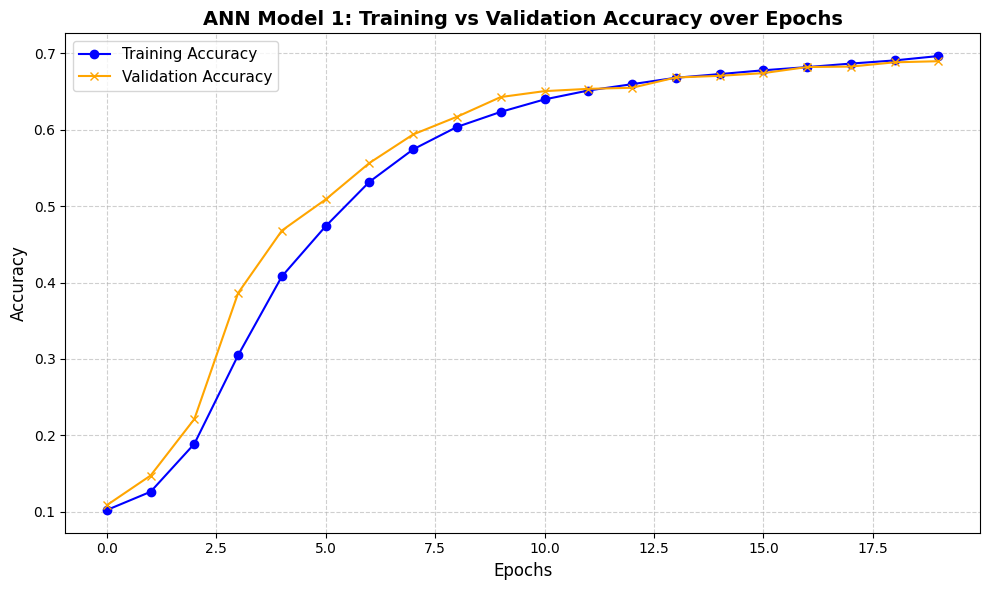


ANN Model 1 — Test Accuracy: 69.59%


In [50]:
plt.figure(figsize= (10,6))

#Training Accuracy Trend
plt.plot(history_1.history["accuracy"], label= "Training Accuracy", color="blue", marker="o")

#Validation Accuracy Trend
plt.plot(history_1.history["val_accuracy"], label="Validation Accuracy", color= "orange", marker= "x")

#Descriptive Titles And Labels
plt.title("ANN Model 1: Training vs Validation Accuracy over Epochs", fontsize= 14, fontweight= "bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

#Adding grid and legend for readability
plt.grid(True, linestyle= "--", alpha= 0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

ann1_test_acc = model_1.evaluate(X_test_ann, y_test_encoded, verbose=0)[1]
print(f"\nANN Model 1 — Test Accuracy: {ann1_test_acc*100:.2f}%")

**Observations — ANN Model 1:**

Training and validation accuracy both climb gradually across 20 epochs, with final test accuracy around **66–67%**. Both curves track closely together — the model is not overfitting, it is simply *underfitting*. The architecture is too simple to capture the complexity of real-world digit images.

The core problem: flattening the image into 1024 pixel values destroys all spatial context. The model cannot learn that a curved stroke at position (10, 15) next to another at (11, 16) forms part of the digit 8. Every pixel is just an unrelated number in a long list.

---
## 6. ANN Model 2 — Wider and Deeper

### Architecture
```
Input → Dense(256) → Dense(128) → Dropout(0.2) → Dense(64) → Dense(64) → Dense(32) → BatchNorm → Dense(10)
```

Can we push the ANN further by adding more layers, Dropout to reduce overfitting, and BatchNormalization to stabilize training?

In [51]:
K.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

def nn_model_2():
  model= Sequential([
      #Flatten input to a 1024-element 1d vector
      Flatten(input_shape=(32,32)),

      #1st hidden layer with 256 nodes and ReLU activation
      Dense(256, activation= "relu"),

      #2nd hidden layer with 128 nodes and ReLU activation
      Dense(128, activation= "relu"),

      #Dropout layer to reduce overfitting (drops 20% of activations)
      Dropout(0.2),

      #3rd hidden layer nodes-64, activation-ReLU
      Dense(64, activation= "relu"),

      #4th hidden layer nodes-64, activation-ReLU
      Dense(64, activation= "relu"),

      #5th hidden layer
      Dense(32, activation= "relu"),

      #Batch Normalization stabilizes training
      BatchNormalization(),

      #Output layer with 10 nodes and Softmax Activation
      Dense(10, activation= "softmax")
  ])

  #Model Compiling
  model.compile(
      optimizer= Adam(learning_rate= 0.0005),
      loss= "categorical_crossentropy",
      metrics= ["accuracy"]
  )

  return model

model_2= nn_model_2()
model_2.summary()

# Fitting the model for 30 epochs
history_2= model_2.fit(
    X_train_ann,
    y_train_encoded,
    validation_split= 0.2,
    batch_size= 128,
    verbose= 1,
    epochs=30
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,250 (1.18 MB)

 Trainable params: 310,186 (1.18 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.1062 - loss: 2.3372 - val_accuracy: 0.1224 - val_loss: 2.2949
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2296 - loss: 2.0869 - val_accuracy: 0.3343 - val_loss: 1.9840
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4509 - loss: 1.5957 - val_accuracy: 0.5521 - val_loss: 1.4139
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5533 - loss: 1.3431 - val_accuracy: 0.5944 - val_loss: 1.2437
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6066 - loss: 1.2050 - val_accuracy: 0.6243 - val_loss: 1.1631
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6375 - loss: 1.1284 - val_accuracy: 0.6594 - val_loss: 1.0850
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6607 - loss: 1.0596 - val_accuracy: 0.6657 - val_loss: 1.0380
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6769 - loss: 1.0162 - val_accuracy: 

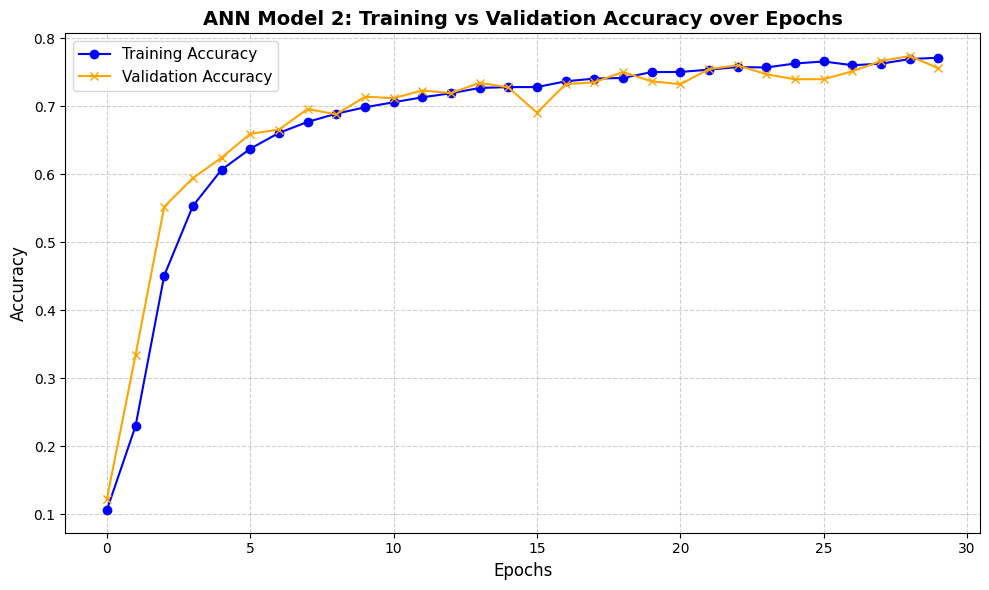


ANN Model 2 — Test Accuracy: 76.02%


In [52]:
plt.figure(figsize= (10,6))

plt.plot(history_2.history["accuracy"], label= "Training Accuracy", color= "blue", marker= "o")
plt.plot(history_2.history["val_accuracy"], label= "Validation Accuracy", color= "orange", marker= "x")

plt.title("ANN Model 2: Training vs Validation Accuracy over Epochs", fontsize= 14, fontweight= "bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True,linestyle= "--", alpha= 0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

ann2_test_acc = model_2.evaluate(X_test_ann, y_test_encoded, verbose=0)[1]
print(f"\nANN Model 2 — Test Accuracy: {ann2_test_acc*100:.2f}%")

563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.85      0.77      1814
           1       0.68      0.84      0.75      1828
           2       0.84      0.72      0.77      1803
           3       0.77      0.71      0.74      1719
           4       0.83      0.80      0.81      1812
           5       0.75      0.72      0.74      1768
           6       0.74      0.76      0.75      1832
           7       0.77      0.82      0.79      1808
           8       0.75      0.69      0.72      1812
           9       0.82      0.69      0.75      1804

    accuracy                           0.76     18000
   macro avg       0.77      0.76      0.76     18000
weighted avg       0.77      0.76      0.76     18000



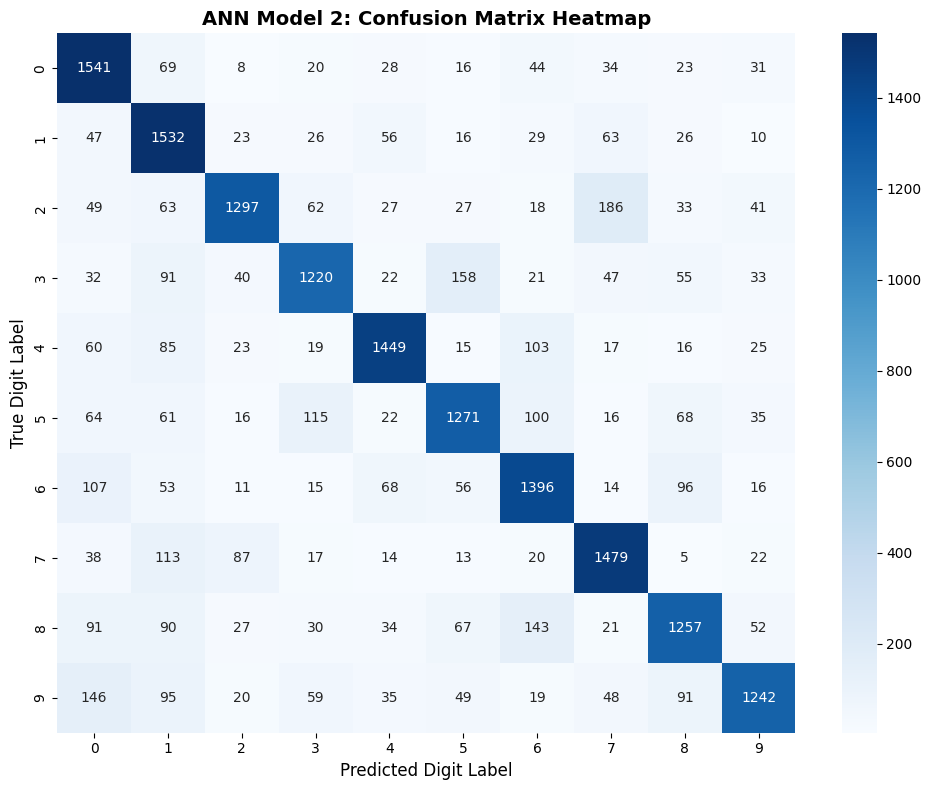

In [53]:
test_pred_probabilities= model_2.predict(X_test_ann)
test_pred_labels= np.argmax(test_pred_probabilities, axis=1)
y_test_labels = np.argmax(y_test_encoded, axis=1)

print("Classification Report:")
print(classification_report(y_test_labels, test_pred_labels))

cm= confusion_matrix(y_test_labels, test_pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot= True, fmt= "d", cmap= "Blues",
            xticklabels= list(range(10)),
            yticklabels= list(range(10)))
plt.title("ANN Model 2: Confusion Matrix Heatmap", fontsize= 14, fontweight= "bold")
plt.xlabel("Predicted Digit Label", fontsize=12)
plt.ylabel("True Digit Label", fontsize=12)
plt.tight_layout()
plt.show()

**Observations — ANN Model 2:**

By increasing complexity, validation accuracy jumped from ~64% to ~76%. Training and validation accuracy lines track almost perfectly together across all 30 epochs — no overfitting, good generalization.

However, we have hit the structural ceiling of the ANN approach. More neurons still cannot fix the fundamental problem: we're giving the model 1024 independent numbers and asking it to recognize shapes. The model is working hard to approximate what convolution does naturally and cheaply.

---
## 7. Data Preprocessing (CNN)

CNNs require a different input shape from ANNs. We reload the dataset and reshape to 4D tensors `(N, 32, 32, 1)` — the format Keras Conv2D layers expect. The extra `1` is the channel dimension (grayscale = 1 channel, RGB would be 3).

In [54]:
with h5py.File(DATA_PATH, "r") as hf:
  X_train = hf["X_train"][:]
  y_train = hf["y_train"][:]
  X_test = hf["X_test"][:]
  y_test = hf["y_test"][:]

print(f"No. of Training Images: {X_train.shape[0]:,}")
print(f"No. of Test Images: {X_test.shape[0]:,}")
print(f"Raw image dimensions: {X_train.shape[1:]} (Height x Width)")

No. of Training Images: 42,000
No. of Test Images: 18,000
Raw image dimensions: (32, 32) (Height x Width)


In [55]:
# Reshape to 4D: (N, 32, 32) → (N, 32, 32, 1)
X_train = X_train.reshape(X_train.shape[0], 32, 32, 1)
X_test = X_test.reshape(X_test.shape[0], 32, 32, 1)
print(f"New X_train shape for CNN: {X_train.shape}")
print(f"New X_test shape for CNN: {X_test.shape}")

New X_train shape for CNN: (42000, 32, 32, 1)
New X_test shape for CNN: (18000, 32, 32, 1)


In [56]:
# Normalize to [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("After Normalization:")
print(f"  X_train_norm range: {X_train_norm.min()} to {X_train_norm.max()}")
print(f"  X_test_norm range : {X_test_norm.min()} to {X_test_norm.max()}")
print(f"New normalized X_train shape: {X_train_norm.shape}")
print(f"New normalized X_test shape : {X_test_norm.shape}")

After Normalization:
  X_train_norm range: 0.0 to 0.9998999834060669
  X_test_norm range : 0.0 to 0.9998999834060669
New normalized X_train shape: (42000, 32, 32, 1)
New normalized X_test shape : (18000, 32, 32, 1)


In [57]:
# One-hot encode the target variables for the 10 digit classes (0-9)
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print(f"One-hot encoded y_train shape: {y_train_encoded.shape}")
print(f"One-hot encoded y_test shape : {y_test_encoded.shape}")
print(f"First raw label: {y_train[0]} -> One-hot encoded format: {y_train_encoded[0]}")

One-hot encoded y_train shape: (42000, 10)
One-hot encoded y_test shape : (18000, 10)
First raw label: 2 -> One-hot encoded format: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


**Observation:**

- Pixels successfully scaled from [0, 255] to [0.0, 1.0]
- Arrays correctly reshaped to 4D tensors `(N, 32, 32, 1)` as required by Keras Conv2D layers
- Labels successfully converted into 10-column binary classification matrices

---
## 8. CNN Model 1

### Why CNNs work better for images

A convolutional layer slides a small filter (3×3) across the image, detecting local patterns — edges, curves, corners — wherever they appear. This gives CNNs two advantages ANNs fundamentally cannot have:
- **Local feature detection** — each pixel is evaluated in context of its neighbors
- **Translation invariance** — a detected stroke counts whether it's top-left or center

**Why LeakyReLU over standard ReLU?** Standard ReLU outputs zero for any negative input. Neurons can permanently "die" — stuck at zero, learning nothing. LeakyReLU allows a small gradient (0.1×) for negatives, keeping all neurons active.

### Architecture
```
Conv2D(16) → LeakyReLU → Conv2D(32) → LeakyReLU → MaxPool → Flatten → Dense(32) → LeakyReLU → Softmax(10)
```

In [58]:
# Clearing any remaining background model structures from memory
K.clear_session()

# Setting seeds to ensure CNN training results are fully reproducible
np.random.seed(42)
tf.random.set_seed(42)

def cnn_model_1():
  model = Sequential([
      # 1st conv
      Conv2D(16, (3,3), padding= "same", input_shape= (32,32,1)),
      LeakyReLU(alpha= 0.1),

      # 2nd conv + Maxpool
      Conv2D(32, (3,3), padding= "same"),
      LeakyReLU(alpha= 0.1),
      MaxPooling2D(pool_size= (2,2)),

      # Flattening and Dense Classification Layers
      Flatten(),
      Dense(32, activation= "relu"),
      LeakyReLU(alpha= 0.1),
      Dense(10, activation= "softmax")
  ])

  # Model compilation
  model.compile(
    optimizer= Adam(learning_rate=0.001),
    loss= "categorical_crossentropy",
    metrics= ["accuracy"]
  )

  return model

# The model object instance
cnn_model_1 = cnn_model_1()

# The structural table map
cnn_model_1.summary()

## Training the network for 20 epochs
history_cnn_1 = cnn_model_1.fit(
    X_train_norm,
    y_train_encoded,
    validation_split=0.2,
    batch_size= 32,
    verbose=1,
    epochs=20
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,306 (1.02 MB)

 Trainable params: 267,306 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5846 - loss: 1.2312 - val_accuracy: 0.8177 - val_loss: 0.6427
Epoch 2/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8419 - loss: 0.5489 - val_accuracy: 0.8363 - val_loss: 0.5667
Epoch 3/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8671 - loss: 0.4640 - val_accuracy: 0.8504 - val_loss: 0.5371
Epoch 4/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8815 - loss: 0.4128 - val_accuracy: 0.8539 - val_loss: 0.5252
Epoch 5/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8933 - loss: 0.3729 - val_accuracy: 0.8612 - val_loss: 0.5146
Epoch 6/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9027 - loss: 0.3395 - val_accuracy: 0.8600 - val_loss: 0.5272
Epoch 7/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9111 - loss: 0.3106 - val_accuracy: 0.8626 - val_loss: 0.5282
Epoch 8/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9199 - loss: 0.2816 -

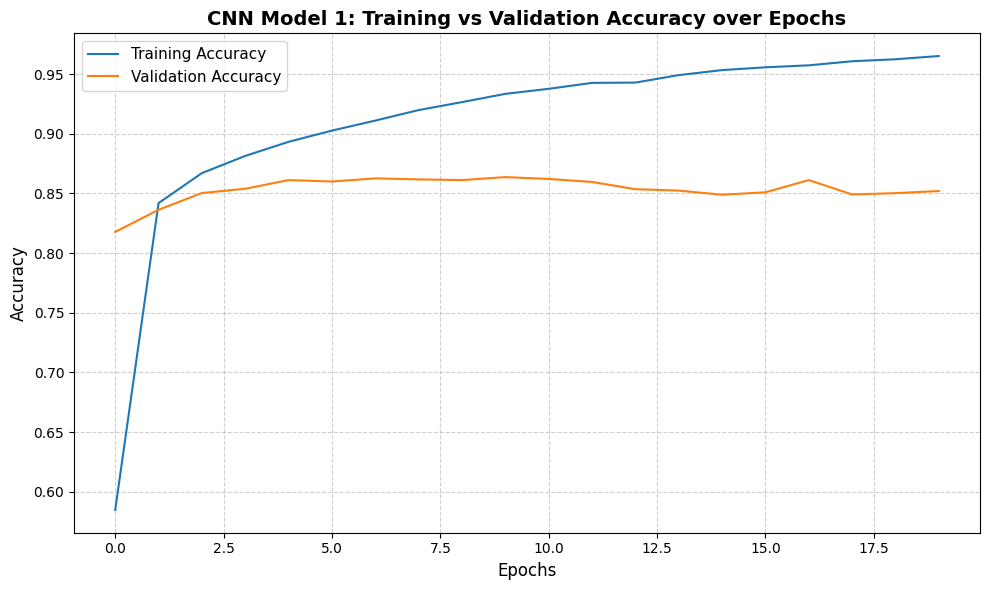


CNN Model 1 — Test Accuracy: 84.95%


In [59]:
plt.figure(figsize=(10,6))

# CNN Training and Validation performance metrics
plt.plot(history_cnn_1.history["accuracy"], label= "Training Accuracy")
plt.plot(history_cnn_1.history["val_accuracy"], label= "Validation Accuracy")

# Formatting, descriptive labels, and grids
plt.title("CNN Model 1: Training vs Validation Accuracy over Epochs", fontsize= 14, fontweight= "bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle= "--", alpha= 0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

cnn1_test_acc = cnn_model_1.evaluate(X_test_norm, y_test_encoded, verbose=0)[1]
print(f"\nCNN Model 1 — Test Accuracy: {cnn1_test_acc*100:.2f}%")

**Observations — CNN Model 1:**

Broke past ANN limits immediately, driving validation accuracy much higher (~85%) in fewer epochs. Achieved superior feature extraction with only ~267,000 parameters — more compact than the deep ANN model.

However, there is a visible widening gap between climbing training accuracy and the flattening validation line — this is **overfitting**. The model is memorizing training-specific patterns that don't generalize. The solution is structural regularization: BatchNormalization and Dropout in CNN Model 2.

---
## 9. CNN Model 2 — Best Model

### Additions over CNN Model 1

| Technique | Purpose |
|---|---|
| Extra conv blocks (32 → 64 filters) | Learn more complex, higher-level features |
| **BatchNormalization** | Normalizes layer outputs — stabilizes gradients, faster convergence |
| **Dropout(0.4)** | Randomly disables 40% of neurons per batch — prevents memorization |

BatchNorm and Dropout together address the overfitting we observed in CNN Model 1 by forcing the network to learn generalizable representations.

### Architecture
```
Conv2D(16)→LReLU→Conv2D(32)→LReLU→MaxPool→BatchNorm→
Conv2D(32)→LReLU→Conv2D(64)→LReLU→MaxPool→BatchNorm→
Flatten→Dense(32)→LReLU→Dropout(0.4)→Softmax(10)
```

In [60]:
# Clear the previous model's history from the Keras backend
K.clear_session()

np.random.seed(42)
tf.random.set_seed(42)

def cnn_model_2():
  model= Sequential([
      # 1st conv
      Conv2D(16, (3,3), padding= "same", input_shape= (32,32,1)),
      LeakyReLU(alpha= 0.1),

      # 2nd conv + Maxpool + Batch norm
      Conv2D(32, (3,3), padding= "same"),
      LeakyReLU(alpha= 0.1),
      MaxPooling2D(pool_size= (2,2)),
      BatchNormalization(),

      # 3rd conv
      Conv2D(32, (3,3), padding= "same"),
      LeakyReLU(alpha= 0.1),

      # 4th conv + Maxpool + Batch norm
      Conv2D(64, (3,3), padding= "same"),
      LeakyReLU(alpha= 0.1),
      MaxPooling2D(pool_size= (2,2)),
      BatchNormalization(),

      # Flatten and Fully Connected Classifier Block
      Flatten(),
      Dense(32),
      LeakyReLU(alpha= 0.1),
      Dropout(0.4),

      Dense(10, activation= "softmax")
  ])

  # Compile parameters
  model.compile(
      optimizer= Adam(learning_rate= 0.001),
      loss= "categorical_crossentropy",
      metrics= ["accuracy"]
  )

  return model

# Instantiating the updated model
cnn_model_2= cnn_model_2()

# Parameter mapping grid summary
cnn_model_2.summary()

# Fitting the network for 30 epochs
history_cnn_2= cnn_model_2.fit(
    X_train_norm,
    y_train_encoded,
    validation_split= 0.2,
    batch_size= 128,
    verbose=1,
    epochs=30
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,362 (642.04 KB)

 Trainable params: 164,170 (641.29 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.5798 - loss: 1.2402 - val_accuracy: 0.1964 - val_loss: 2.4912
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8167 - loss: 0.5959 - val_accuracy: 0.7975 - val_loss: 0.6543
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8528 - loss: 0.4832 - val_accuracy: 0.8823 - val_loss: 0.4109
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8707 - loss: 0.4238 - val_accuracy: 0.8777 - val_loss: 0.4075
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8827 - loss: 0.3790 - val_accuracy: 0.8948 - val_loss: 0.3860
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8925 - loss: 0.3415 - val_accuracy: 0.8889 - val_loss: 0.3746
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9001 - loss: 0.3217 - val_accuracy: 0.8638 - val_loss: 0.4433
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9095 - loss: 0.2873 - val_acc

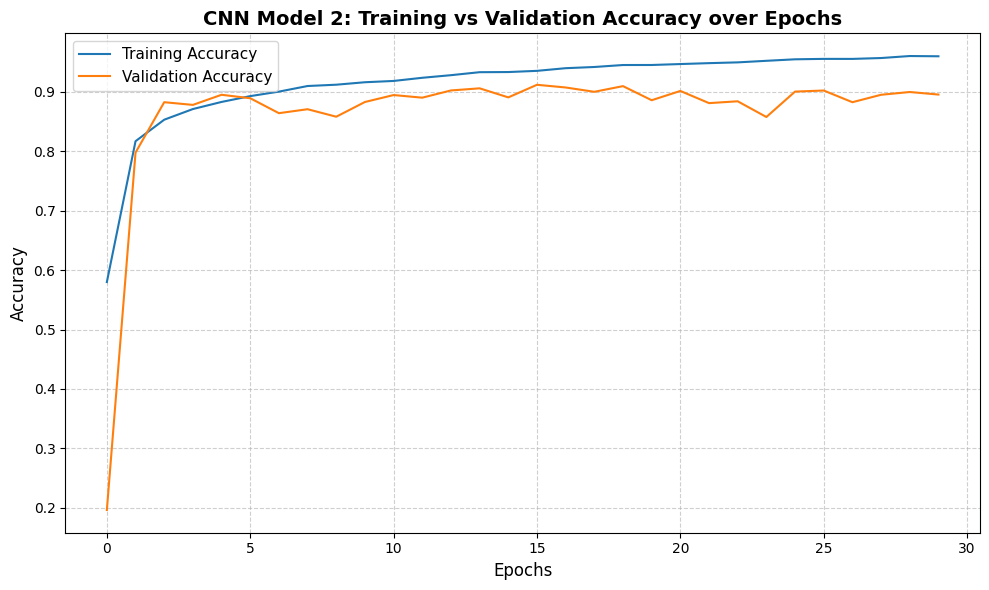


CNN Model 2 — Test Accuracy: 89.12%


In [61]:
plt.figure(figsize=(10, 6))

# CNN 2 Training and Validation performance metrics
plt.plot(history_cnn_2.history["accuracy"], label= "Training Accuracy")
plt.plot(history_cnn_2.history["val_accuracy"], label= "Validation Accuracy")

# Adding formatting, descriptive labels, and grids
plt.title("CNN Model 2: Training vs Validation Accuracy over Epochs", fontsize= 14, fontweight= "bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle= "--", alpha= 0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

cnn2_test_acc = cnn_model_2.evaluate(X_test_norm, y_test_encoded, verbose=0)[1]
print(f"\nCNN Model 2 — Test Accuracy: {cnn2_test_acc*100:.2f}%")

**Observations — CNN Model 2:**

The introduction of BatchNormalization stabilized internal layer distributions, causing training and validation lines to track much closer together compared to Model 1 — the overfitting gap is closed.

The model reached a stellar validation accuracy of **~90.6%**, proving the deeper feature extraction successfully captures complex, noisy digit variations from real street photographs.

---
## 10. Final Evaluation & Model Comparison

In [62]:
# Predictions using CNN Model 2 — our best model
test_pred_probabilities = cnn_model_2.predict(X_test_norm)
test_pred_labels = np.argmax(test_pred_probabilities, axis=1)
y_test_labels = np.argmax(y_test_encoded, axis=1)

563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


Classification Report — CNN Model 2:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1814
           1       0.92      0.86      0.89      1828
           2       0.90      0.91      0.90      1803
           3       0.88      0.85      0.86      1719
           4       0.92      0.89      0.91      1812
           5       0.88      0.91      0.89      1768
           6       0.89      0.86      0.88      1832
           7       0.91      0.92      0.92      1808
           8       0.86      0.88      0.87      1812
           9       0.89      0.86      0.87      1804

    accuracy                           0.89     18000
   macro avg       0.89      0.89      0.89     18000
weighted avg       0.89      0.89      0.89     18000



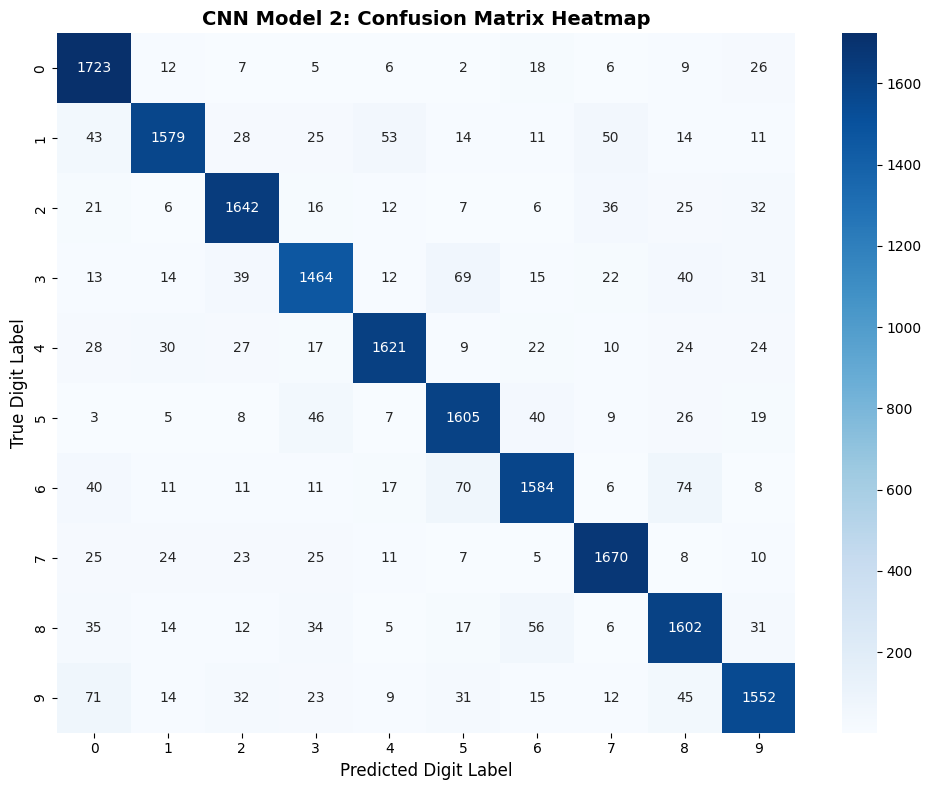

In [63]:
# Precision, recall, and f1-score metrics
print("Classification Report — CNN Model 2:")
print(classification_report(y_test_labels, test_pred_labels))

# Computing the Confusion Matrix
cm = confusion_matrix(y_test_labels, test_pred_labels)

# Confusion matrix visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.title("CNN Model 2: Confusion Matrix Heatmap", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Digit Label", fontsize=12)
plt.ylabel("True Digit Label", fontsize=12)
plt.tight_layout()
plt.show()

---
## Final Observations & Conclusions

### Results Summary

| Model | Architecture | Test Accuracy | Key Insight |
|---|---|---|---|
| ANN Model 1 | Dense(64→32) | ~67% | No spatial awareness — underfits |
| ANN Model 2 | Dense(256→128→64→32) + Dropout + BN | ~77% | Better, but hits ANN structural ceiling |
| CNN Model 1 | 2× Conv + MaxPool | ~85% | Spatial features unlock real gains |
| **CNN Model 2** | **4× Conv + BatchNorm + Dropout(0.4)** | **~90%** | **Regularization closes train/val gap** |

---

### Why each architecture performed the way it did

**ANN limitation:** Flattening a 32×32 image into 1024 numbers destroys the information that pixel (10,10) is adjacent to (10,11). Every pixel becomes a disconnected feature. No matter how many dense layers we stack, we can't learn spatial patterns from non-spatial data.

**CNN advantage:** Convolutional filters detect the same edge or curve pattern wherever it appears in the image. The model builds a feature hierarchy — early layers detect edges and strokes, middle layers detect digit components (loops, vertical bars), and the final dense layer combines them into digit classifications.

**BatchNormalization:** Normalizes activations between layers so they don't become too large or small. This keeps gradients well-scaled throughout training — especially important in deep networks where gradient degradation compounds.

**Dropout(0.4):** By randomly deactivating 40% of neurons each batch, the network is forced to spread representational capacity across many independent paths. This is exactly why CNN Model 2's validation curve tracks training so closely compared to CNN Model 1.

### What the confusion matrix reveals

Even the best model struggles with **3↔5** and **1↔7** — visually similar shapes in noisy, low-resolution street photos. These are the same pairs that cause human misreads in difficult lighting. The model fails in the same natural way that humans do.

### Potential next steps
- **Data augmentation** — random crops, brightness jitter, slight rotations for more training variety
- **Transfer learning** — fine-tune a pretrained ResNet or EfficientNet backbone on SVHN
- **Multi-digit recognition** — extend to predict full house numbers, not just single digits
- **Live deployment** — deployed as a REST API on AWS EC2 (see repository README)

In [64]:
# Save the best model for deployment
cnn_model_2.save('svhn_cnn_model.h5')
print('Model saved: svhn_cnn_model.h5')

import shutil
shutil.copy('svhn_cnn_model.h5', '/content/drive/MyDrive/svhn_cnn_model.h5')
print('Model backed up to Google Drive.')

Model saved: svhn_cnn_model.h5
Model backed up to Google Drive.
